# dependencies: papermill and scrapbook

In [1]:
!ls
!pip install scrapbook
!pip install papermill
!pip install adjustText

Ag_Plot_Test_Protocol.ipynb    ag13628	ag13673  ag13685  ag13687  ag13722
Preliminary_Scurve_2025.ipynb  ag13658	ag13674  ag13686  ag13708  ag13755
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [1]:
import papermill as pm
import scrapbook as sb
import numpy as np
from matplotlib import pyplot as plt
from adjustText import adjust_text
import pandas as pd

In [5]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 KB 5.3 MB/s eta 0:00:00a 0:00:01


# Get Chuckman Simulation

In [31]:
df = pd.read_excel("../chuckman_simulation/250914_103516_vertices.xlsx")

print(df.head())

print(df.columns.tolist())

typeSimulation = np.array(df['Octupole current during release (A)'].tolist())
biases_sim = np.array(df['Trap bias (g)'])
duration = np.array(df['Ramp duration per segment (s)'])

segment6_up   = df['Window 6 up'].tolist()
segment6_down = df['Window 6 down'].tolist()

segment7_up   = df['Window 7 up'].tolist()
segment7_down = df['Window 7 down'].tolist()

TotUp = np.array(segment7_up) + np.array(segment6_up)
TotDown = np.array(segment7_down) + np.array(segment6_down)

simulation = TotDown / (TotUp + TotDown)

mask = (typeSimulation == 830)

print(mask)

simulation_870 = simulation[mask]
biases_sim_870 = biases_sim[mask]

mask = (typeSimulation == 275) & (duration == 10)

simulation_275 = simulation[mask]
biases_sim_275 = biases_sim[mask]

print(biases_sim_275, simulation_275)

   Ramp duration per segment (s)  Octupole current during release (A)  \
0                             10                                  275   
1                             10                                  275   
2                             10                                  275   
3                             10                                  275   
4                             10                                  275   

   Trap bias (g)  Window 1  WIndow 2  Window 3  Window 4  Window 5  \
0          -0.50       224        71       183      1812       508   
1          -0.20       226        72       202      1863       480   
2          -0.05       231        71       163      1868       461   
3           0.00       196        65       134      1514       361   
4           0.05       209        56       151      1458       370   

   Window 6 down  Window 6 mid  Window 6 up  Window 7 down  Window 7 mid  \
0              4             0          100              0      

# Dictionary to link the run at the nominal bias
# Modify this by adding manually the runs

In [12]:
# add entry here ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
dictRun = {"ag13674/ag13674.vertex.csv": 0,
          "ag13673/ag13673.vertex.csv": 0,
           "ag13686/ag13686.vertex.csv" : -0.8, 
          "ag13685/ag13685.vertex.csv": -1.2,
          "ag13687/ag13687.vertex.csv": -1.2,
          "ag13708/ag13708.vertex.csv": -2.0,
          "ag13722/ag13722.vertex.csv": -10.0
          }

In [13]:
# Extract Preliminary S-curve

In [17]:
S  = []
dS = []
bias = []
list_runs = []

Ntot_list, Nup_list, Ndown_list = [],[],[]
Knife_tot_list, Knife_cb, Knife_da = [],[],[]

for key, bias_ in dictRun.items():
    print(key)
    pm.execute_notebook(
        'Ag_Plot_Test_Protocol.ipynb',
        f'{key.split("/")[0].replace("ag","r")}.ipynb',
        parameters= {"run_to_analyze" : key}
    )
    # read result
    nb = sb.read_notebook(f'{key.split("/")[0].replace("ag","r")}.ipynb')
    
    print(nb.scraps["my_result"].data)
    
    Sextr, dSextr = nb.scraps["my_result"].data[0], nb.scraps["my_result"].data[1]
    
    S.append(Sextr); dS.append(dSextr)
    
    bias.append(bias_)
    
    list_runs.append(key.split("/")[0].replace("ag","r"))

    # read all the data
    Ntot, Nup, Ndown = nb.scraps["tot_counts"].data[0], nb.scraps["tot_counts"].data[1], nb.scraps["tot_counts"].data[2]
    Ntot_list.append(Ntot)
    Knife_tot, Knife_cb, Knife_da = nb.scraps["tot_knife"].data[0], nb.scraps["tot_knife"].data[1], nb.scraps["tot_knife"].data[2]
    Knife_tot_list.append(Knife_tot)

ag13674/ag13674.vertex.csv


Executing:   0%|          | 0/21 [00:00<?, ?cell/s]

[0.978350890987643, 0.02514862402481194]
ag13673/ag13673.vertex.csv


Executing:   0%|          | 0/21 [00:00<?, ?cell/s]

[1.0061636748235285, 0.009823562796371827]
ag13686/ag13686.vertex.csv


...

[0.47305518445265293, 0.0683014011423354]
ag13708/ag13708.vertex.csv


Executing:   0%|          | 0/21 [00:00<?, ?cell/s]

[0.01862618944020889, 0.02153261841810256]
ag13722/ag13722.vertex.csv


Executing:   0%|          | 0/21 [00:00<?, ?cell/s]

[0.03223708310469197, 0.02393196635128473]


In [32]:
S = np.array(S)
dS = np.array(dS)
bias = np.array(bias)
list_runs = np.array(list_runs)

bias; S=Ndwn/(Ntot) ; dS
| 0.00g,	  0.98,	 0.025
| 0.00g,	  1.01,	 0.0098
| -0.80g,	  0.69,	 0.073
| -1.20g,	  0.23,	 0.038
| -1.20g,	  0.47,	 0.068
| -2.00g,	  0.02,	 0.022
| -10.00g,	  0.03,	 0.024
[False False False  True False False False]


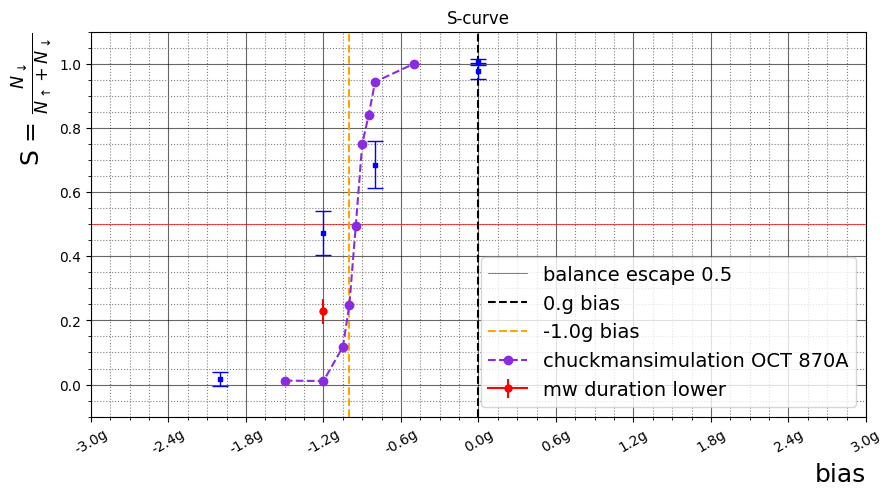

In [39]:
print("bias; S=Ndwn/(Ntot) ; dS")
for bias_, asymmetry, error in zip(bias, S, dS):
    print(f"| {bias_:.2f}g,\t  {asymmetry:.2f},\t {error:.2}")


plt.figure(1, figsize = (10, 5))
plt.title("S-curve")
plt.ylabel(r"S = $\frac{N_{\downarrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
plt.xlabel("bias", loc = 'right', fontsize = 18)

plt.grid()
plt.minorticks_on()
plt.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
plt.ylim(-0.1,1.1)
#plt.xlim(-3, 3)

#######
plt.errorbar(biases_sim_870 - 1, simulation_870, marker = ".", markersize = 12, linestyle = "--", color = "blueviolet", label = "chuckmansimulation OCT 870A")
#######

plt.axhline(0.5, linestyle = "-", color = "red", alpha = 1, linewidth = 0.5, label = "balance escape 0.5")
plt.axvline(0, linestyle = "--", color = "black", label = "0.g bias")
plt.axvline(-1, linestyle = "--", color = "orange", label = "-1.0g bias")
plt.xlim(-3,3)

mask = (list_runs == "r13685")
print(mask)
plt.errorbar(bias[~mask], S[~mask], dS[~mask], marker = "s", markersize = 3, color = "blue", capsize = 6, elinewidth=1, linestyle = "")
plt.errorbar(bias[mask], S[mask], dS[mask], color="red", markersize=10, marker=".", label = "mw duration lower")  # evidenzio il terzo punto

labels = np.linspace(-3,3,11)
plt.xticks(labels,[f"{item:.1f}g" for item in labels], rotation = 30)      # etichette

# metto una etichetta vicino a ogni punto
#for xi, yi, label in zip(bias, S, list_runs):
#    plt.text(xi-0.07, yi, label, fontsize=10, ha="right", va="bottom")

texts = []
#for xi, yi, label in zip(bias, S, list_runs):
#    texts.append(plt.text(xi - 0.8, yi, label))

#adjust_text(texts, bias, S, arrowprops=dict(arrowstyle="->", color='gray'))

plt.legend(fontsize = 14, loc = "lower right")
plt.savefig("S_curve.png", bbox_inches = 'tight')

In [10]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"